# PROYECTO MACHINE LEARNING K-NEARST NEIGHBORS (KNN) CLASSIFIER

**Autor:** Efren Cherres Bowen

**Fecha:** 21 Mayo del 2026

**Metodologia:** CRISP-DM (6 FASES)

**Dataset:** BREAST CANCER WISCONSIN
__________________________________________________________________________

## Introducción:

El Breast Cancer Wisconsin (Diagnostic) Dataset es un conjunto de datos ampliamente utilizado en Machine Learning y analisis perdictivo para la deteccion de cancer de mama. El dataset contiene caracteristicas obtenidas a partir de imagenes digitalizadas de biopsias mamarias donde se analizan propiedades celulares como tamaño, textura, perimetro, area y concavidad del tumor.

El objetivo principal del dataset es clasificar los tumores en:

Benignios: (B)
Malignos: (M)

mediante técnicas de clasificacion supervisada que en este caso es KNN Classifier.

## FASE 1. COMPRENSION DEL NEGOCIO (BUSINESS UNDERSTANDING)

Los centros medicos necesitan detectar de manera temprana si un tumor puede ser maligno para mejorar el tratamiento y reducir riesgos para los pacientes.

**Objetivo del proyecto:** 
Desarrollar un modelo de Machine Learning utilizando KNN Classifier capaz de clasificar tumores como benignos o malignos.

**Objetivo analítico:**
Construir un modelo predictivo de clasificación supervisado en caracteristicas celulares del tumor.

### Inicializacion del entorno analítico y carga de dependencias.

En esta fase se realizará la cofiguración del entorno de trabajo mediante la importación de las librerias especializadas de python requeridas para el desarrollo del modelo predictivo.

Estas dependencias nos proporcionan las capacidades necesarias para la manipulación y transformación de datos, análisis exploratorio, visualización estadististica, preprocesamiento, entrenamiento del algoritmo KNNClassifier y evaluacion del desempeño del modelo.

La correcta inicialización del entorno nos garantiza consistencia, reproducibilidad y eficiencia durante todo el flujo analitico del proyecto.

#### Importación de las Librerias.

In [44]:
# Libreria para manipulacion y análisis de la data
import pandas as pd 

# Libreria para operaciones numericas.
import numpy as np 

# Libreria para graficos.
import matplotlib.pyplot as plt

# Liberia para graficos estadisticos 
import seaborn as sns

# Funcion para dividir datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Estandarizacion de datos
from sklearn.preprocessing import StandardScaler

# Modelo KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

# Metricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# warnigs se utiliza para controlar mensajes de advertencia
import warnings

# desactivar las advertencias para mantener la salida del notebook de manera limpia y consisa 
warnings.filterwarnings("ignore")

# Configuracion de pandas para mostrar numeros decimales con 4 cifras despues del punto
pd.set_option("display.float_format","{:.4f}".format)

# Importar la clase de figure matplotlib para crear y personalizar figuras graficas
from matplotlib.figure import Figure

# Configurar el visual de los graficos
plt.rcParams["figure.figsize"] = (10,6)

#### Cargar el Dataset.

In [45]:
# Cargar el dataset de cancer de mama
df_cancer = pd.read_csv("data.csv")

# Muestra del Dataset de forma tabular y organizada.
display(df_cancer)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,NaN
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,NaN
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,NaN
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.5600,22.3900,142.0000,1479.0000,0.1110,0.1159,0.2439,0.1389,0.1726,0.0562,1.1760,1.2560,7.6730,158.7000,0.0103,0.0289,0.0520,0.0245,0.0111,0.0042,25.4500,26.4000,166.1000,2027.0000,0.1410,0.2113,0.4107,0.2216,0.2060,0.0712,NaN
565,926682,M,20.1300,28.2500,131.2000,1261.0000,0.0978,0.1034,0.1440,0.0979,0.1752,0.0553,0.7655,2.4630,5.2030,99.0400,0.0058,0.0242,0.0395,0.0168,0.0190,0.0025,23.6900,38.2500,155.0000,1731.0000,0.1166,0.1922,0.3215,0.1628,0.2572,0.0664,NaN
566,926954,M,16.6000,28.0800,108.3000,858.1000,0.0846,0.1023,0.0925,0.0530,0.1590,0.0565,0.4564,1.0750,3.4250,48.5500,0.0059,0.0373,0.0473,0.0156,0.0132,0.0039,18.9800,34.1200,126.7000,1124.0000,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782,NaN
567,927241,M,20.6000,29.3300,140.1000,1265.0000,0.1178,0.2770,0.3514,0.1520,0.2397,0.0702,0.7260,1.5950,5.7720,86.2200,0.0065,0.0616,0.0712,0.0166,0.0232,0.0062,25.7400,39.4200,184.6000,1821.0000,0.1650,0.8681,0.9387,0.2650,0.4087,0.1240,NaN


## FASE 2. COMPRENSION DE LOS DATOS (DATA UNDERSTANDING)

#### Insight del Dataset

El dataset contiene caracteristicas celulares utilizadas para clasificar tumores como:

- `Benignos (B)`
- `Malignos (M)`

Se observa que los tumores malignos presentan valores más altos en variables como ***radius_mean, perimeter_mean y area_mean*** indicando un crecimiento mas agresivo.

Por ejemplo se observa valores de ***area_mean = 1000*** lo que refleja tumpores de mayor tamaño.

Ademas variables relacionadas con irregularidades celulares como: 
- concavity_mean = `0.3001`
- concave points_mean = `0.14710`

que muestran bordes mas deformes y agresivos en tumores malignos, siendo factores importantes para la clasificación con KNNClassifer.

**Otras observaciones:**

- **La columna Unnamed:32** contiene únicamente valores nulos y debe eliminarse.
- **Las variables son numericas continuas** por lo tanto son ideales para KNN
- **Existen diferencias grandes de escala entre variables** por ejemplo:
    - smoothnees_mean = 0.1
    - area_mean = 1000
  
Por ello es necesario aplicar normalizacion con StandardScaler antes del entrenamiento del modelo. 


#### Análsis exploratorio y evaluación estructural del dataset

In [46]:
# Mostrar cantidad de filas y columnas del dataset.
print("Dimensiones del dataset:")
print(f"Registros(filas):{df_cancer.shape[0]}")
print(f"Columnas: {df_cancer.shape[1]}")

Dimensiones del dataset:
Registros(filas):569
Columnas: 33


In [47]:
# Mostrar informacion general del dataset
print("\nInformación del dataset:")
print(df_cancer.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  

In [48]:
# Mostrar las estadisticas basicas descriptivas
print("\nEstadisticas descriptivas:")
display(df_cancer.describe())


Estadisticas descriptivas:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,0.0000
mean,30371831.4323,14.1273,19.2896,91.9690,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,0.4052,1.2169,2.8661,40.3371,0.0070,0.0255,0.0319,0.0118,0.0205,0.0038,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,NaN
std,125020585.6122,3.5240,4.3010,24.2990,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,0.2773,0.5516,2.0219,45.4910,0.0030,0.0179,0.0302,0.0062,0.0083,0.0026,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,NaN
min,8670.0000,6.9810,9.7100,43.7900,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,0.1115,0.3602,0.7570,6.8020,0.0017,0.0023,0.0000,0.0000,0.0079,0.0009,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,NaN
25%,869218.0000,11.7000,16.1700,75.1700,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,0.2324,0.8339,1.6060,17.8500,0.0052,0.0131,0.0151,0.0076,0.0152,0.0022,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,NaN
50%,906024.0000,13.3700,18.8400,86.2400,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,0.3242,1.1080,2.2870,24.5300,0.0064,0.0204,0.0259,0.0109,0.0187,0.0032,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,NaN
75%,8813129.0000,15.7800,21.8000,104.1000,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,0.4789,1.4740,3.3570,45.1900,0.0081,0.0324,0.0420,0.0147,0.0235,0.0046,18.7900,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,NaN
max,911320502.0000,28.1100,39.2800,188.5000,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,2.8730,4.8850,21.9800,542.2000,0.0311,0.1354,0.3960,0.0528,0.0790,0.0298,36.0400,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075,NaN


### ***Insight estadístico del dataset***

El análisis descriptivo muestra una alta variabilidad en las características celulares del dataset Breast Cancer Wisconsin (Diagnostic) Data Set, especialmente en variables relacionadas con tamaño y forma del tumor, como area_mean, perimeter_mean y radius_mean.

**Se observa que:**

area_mean tiene un promedio de 654.8891, alcanzando valores máximos de 2501.0000, lo que evidencia una gran dispersión entre tumores.
Variables como concavity_mean y concave points_mean presentan mínimos cercanos a 0, pero máximos elevados (0.4268 y 0.2012), indicando diferencias importantes en la irregularidad celular.
La desviación estándar alta en variables como area_worst (569.3570) sugiere presencia de casos con características muy distintas entre sí.

**Además:**

La columna Unnamed: 32 contiene únicamente valores nulos (count = 0), por lo que no aporta información útil y debe eliminarse.
Existen diferencias significativas de escala entre variables, por ejemplo:
smoothness_mean ≈ 0.0964
area_mean ≈ 654.8891

Por ello, es necesario aplicar normalización mediante StandardScaler antes de entrenar el modelo KNeighborsClassifier, ya que KNN depende directamente del cálculo de distancias matemáticas.

## FASE 3. PREPARACION DE LOS DATOS

#### Validación y análisis de valores nulos del dataset.

In [49]:
# Contar valores nulos y calcular porcentaje de la columna.
valores_nulos = df_cancer.isnull().sum()
porcentaje_nulos = (
    df_cancer.isnull().sum()/len(df_cancer))*100

# Crear el resumen de valores nulos
df_nulos = pd.DataFrame({
    "Valores_nulos": valores_nulos,
    "Porcentaje_%": porcentaje_nulos
})

# Mostrar resultado con 4 decimales
display(df_nulos.round(4))


,Valores_nulos,Porcentaje_%
id,0,0.0000
diagnosis,0,0.0000
radius_mean,0,0.0000
texture_mean,0,0.0000
perimeter_mean,0,0.0000
area_mean,0,0.0000
smoothness_mean,0,0.0000
compactness_mean,0,0.0000
concavity_mean,0,0.0000
concave points_mean,0,0.0000


#### Depuración y eliminación de variables no relavantes.

De acuerdo con el análisis exploratorio realizado, se procede a ejecutar la etapa de depuración y selección de variables del dataset, eliminando aquellas columnas que no aportan valor analítico ni relevancia predictiva para el modelo. Este proceso permite reducir ruido en los datos, optimizar el rendimiento computacional y mejorar la calidad del entrenamiento del modelo de Machine Learning, garantizando un conjunto de datos más consistente y adecuado para el análisis predictivo.

In [50]:
# Eliminar la columna Id
df_cancer.drop("id", axis=1, inplace=True)

# Eliminar la columna vacia "Unnamed:32"
df_cancer.drop("Unnamed: 32", axis=1, inplace=True)

display(df_cancer.head())

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


#### Transformación y codificación de la variable objetivo.

En esta etapa se realiza la transformación de la variable objetivo diagnosis, convirtiendo sus categorías textuales en valores numéricos para facilitar el procesamiento por parte del modelo de Machine Learning. Debido a que algoritmos como KNeighborsClassifier trabajan mediante cálculos matemáticos y métricas de distancia, es necesario representar las clases en formato numérico.

***La codificación aplicada es la siguiente:***

- M → 1 (Maligno)
- B → 0 (Benigno)

Este proceso permite que el algoritmo interprete correctamente la variable objetivo durante las fases de entrenamiento, predicción y evaluación del modelo.

In [51]:
df_cancer["diagnosis"] = df_cancer["diagnosis"].map({
    "M": 1,
    "B": 0
})

display(df_cancer)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,1,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,1,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,1,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.5600,22.3900,142.0000,1479.0000,0.1110,0.1159,0.2439,0.1389,0.1726,0.0562,1.1760,1.2560,7.6730,158.7000,0.0103,0.0289,0.0520,0.0245,0.0111,0.0042,25.4500,26.4000,166.1000,2027.0000,0.1410,0.2113,0.4107,0.2216,0.2060,0.0712
565,1,20.1300,28.2500,131.2000,1261.0000,0.0978,0.1034,0.1440,0.0979,0.1752,0.0553,0.7655,2.4630,5.2030,99.0400,0.0058,0.0242,0.0395,0.0168,0.0190,0.0025,23.6900,38.2500,155.0000,1731.0000,0.1166,0.1922,0.3215,0.1628,0.2572,0.0664
566,1,16.6000,28.0800,108.3000,858.1000,0.0846,0.1023,0.0925,0.0530,0.1590,0.0565,0.4564,1.0750,3.4250,48.5500,0.0059,0.0373,0.0473,0.0156,0.0132,0.0039,18.9800,34.1200,126.7000,1124.0000,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782
567,1,20.6000,29.3300,140.1000,1265.0000,0.1178,0.2770,0.3514,0.1520,0.2397,0.0702,0.7260,1.5950,5.7720,86.2200,0.0065,0.0616,0.0712,0.0166,0.0232,0.0062,25.7400,39.4200,184.6000,1821.0000,0.1650,0.8681,0.9387,0.2650,0.4087,0.1240


#### Validación integral de calidad de datos.

Como segundo filtro del proceso analítico, se realiza una verificación integral de la calidad de los datos luego de las etapas de limpieza, eliminación de variables y transformaciones. 

Este control permite confirmar la ausencia de valores nulos, registros vacíos, símbolos inválidos y valores infinitos que puedan comprometer el rendimiento del modelo.

Este paso se considera esencial dentro del flujo CRISP-DM, ya que garantiza la consistencia final del dataset antes del entrenamiento de modelos como KNeighborsClassifier, que es para esto caso, asegurando la confiabilidad y estabilidad de los resultados obtenidos.

In [52]:
# Resumen general del dataset
display(df_cancer.info())

# Consolide las variables para validar la calidad de datos
df_validacion = pd.DataFrame({
    "NaN": df_cancer.isnull().sum(),
    "Vacios": (df_cancer == "").sum(),
    "Simbolo ?": (df_cancer == "?").sum(),
    "Infinitos": np.isinf(
        df_cancer.select_dtypes(include=np.number).sum()
    )
})

# Mostrar resumen consolidad
display(df_validacion)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

None

,NaN,Vacios,Simbolo ?,Infinitos
diagnosis,0,0,0,False
radius_mean,0,0,0,False
texture_mean,0,0,0,False
perimeter_mean,0,0,0,False
area_mean,0,0,0,False
smoothness_mean,0,0,0,False
compactness_mean,0,0,0,False
concavity_mean,0,0,0,False
concave points_mean,0,0,0,False
symmetry_mean,0,0,0,False


### Análisis de distribución de la variable objetivo

Se analiza la distribución de la variable diagnosis para evaluar el balance entre las clases benigno y maligno. Este paso permite identificar posibles desbalances que puedan afectar el desempeño del modelo durante el entrenamiento.

Una distribución equilibrada o conocida es clave en modelos de clasificación como KNeighborsClassifier, ya que influye directamente en su capacidad de generalización y en la confiabilidad de las predicciones.

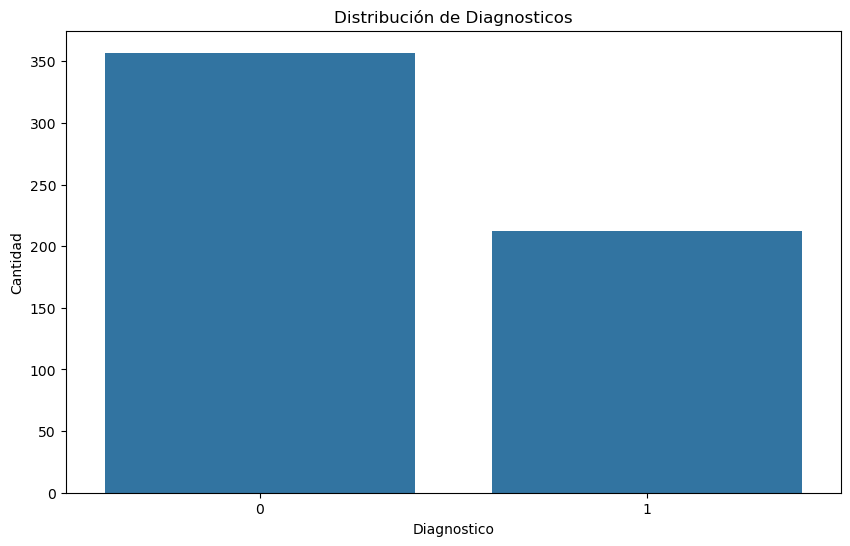

In [53]:
# Crear grafico de conteo
sns.countplot(x=df_cancer["diagnosis"])

# Titulo
plt.title("Distribución de Diagnosticos")

# Etiquetas eje (x) y eje (y)
plt.xlabel("Diagnostico")
plt.ylabel("Cantidad")

# Mostrar el grafico
plt.show()

#### Definición de variables predictoras y variable objetivo en el conjunto de datos.

Se separan las variables predictoras (X) de la variable objetivo (y) para estructurar correctamente el problema de aprendizaje supervisado, definiendo claramente las características que explican el fenómeno.

Esto permite que el modelo identifique relaciones entre variables de entrada y salida de forma consistente, asegurando un entrenamiento más preciso y controlado.

In [54]:
# Se elimina todas las columnas excepto la variable objetivo para construir las variables predictoras.
x = df_cancer.drop("diagnosis", axis=1)

# Se define la variable objetivo que el modelo debe aprender a predecir 
y = df_cancer["diagnosis"]

#### Dividir el Dataset para el entrenamiento y prueba

Se realiza la división de los datos en entrenamiento y prueba para evaluar el rendimiento del modelo de forma objetiva sobre información no vista.

Esto permite medir su capacidad de generalización y evitar sobreajuste, asegurando que los resultados sean representativos en escenarios reales.

In [55]:
# Dividir datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Escalado de Datos 

El escalado de datos se realiza para normalizar las variables numéricas y llevarlas a una escala común, evitando que aquellas con magnitudes mayores dominen el cálculo del modelo.

Esto es especialmente importante en algoritmos basados en distancia como KNeighborsClassifier, ya que mejora la precisión y estabilidad del entrenamiento.

In [56]:
# Se crea una instacia del objeto StandardScaler para estandarizar las variables.
scaler = StandardScaler()

# Se ajusta el escalador con los datos de entrenamiento y prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Revisar el escalado
display(df_scaled.head())



,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.5186,0.8918,0.4246,0.3839,-0.9747,-0.6898,-0.6886,-0.3982,-1.0392,-0.8251,-0.1093,-0.0560,-0.2101,-0.0159,-1.0052,-0.9119,-0.6628,-0.6526,-0.7019,-0.2754,0.5798,1.3132,0.4669,0.4460,-0.5962,-0.6347,-0.6102,-0.2357,0.0546,0.0218
1,-0.5164,-1.6397,-0.5413,-0.5430,0.4762,-0.6318,-0.6043,-0.3031,0.5215,-0.4545,-0.6044,-1.0010,-0.5854,-0.4935,0.4032,-0.7682,-0.4792,0.1145,-0.1430,-0.5774,-0.5825,-1.6903,-0.6119,-0.5870,0.2736,-0.8148,-0.7127,-0.3232,-0.1376,-0.9044
2,-0.3681,0.4555,-0.3882,-0.4030,-1.4330,-0.3839,-0.3422,-0.7655,-0.8509,-0.2262,0.3040,1.0515,-0.1695,-0.0008,-0.3101,1.1063,0.6226,0.2737,0.7545,1.5081,-0.3986,0.1820,-0.4754,-0.4208,-1.6228,-0.3914,-0.4313,-0.8908,-0.6759,-0.1440
3,0.2053,0.7262,0.4003,0.0706,0.2433,2.2036,2.2561,1.2132,0.8185,0.8998,-0.5457,-0.6217,0.2614,-0.3536,0.0245,2.0907,1.4906,1.6951,-0.6549,0.7675,-0.0003,0.2742,0.5138,-0.0995,0.4185,2.8660,2.9586,1.9771,-0.0756,1.7288
4,1.2430,0.1942,1.2104,1.2067,-0.1114,0.0513,0.7330,0.7138,-0.4272,-0.8222,1.5239,1.1439,1.2827,1.0813,1.3518,0.1077,0.5929,1.1810,0.3015,0.1715,1.0128,0.2231,0.9385,0.8809,0.0732,-0.2770,0.3278,0.5019,-0.9093,-0.5462


## FASE 4. MODELADO

#### Crear el Modelo de ML

En esta etapa se entrena el modelo con los datos de entrenamiento para que aprenda patrones entre las variables predictoras y la variable objetivo.

Esto permite generar un sistema capaz de realizar predicciones sobre nuevos datos de forma consistente, utilizando el algoritmo KNeighborsClassifier.

In [57]:
# Crear el modelo KNN
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

#### Entrenamiento del Modelo

En esta fase se ajusta el modelo utilizando los datos de entrenamiento para que aprenda la relación entre las variables predictoras y la variable objetivo.

Este proceso es esencial porque permite al algoritmo identificar patrones y construir una base de conocimiento para realizar predicciones sobre datos nuevos, como en KNeighborsClassifier.

In [58]:
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


#### Realizar las predicciones

En esta etapa se generan las predicciones del modelo a partir de los datos de prueba previamente escalados. Esto permite evaluar cómo se comporta el modelo frente a información que no ha visto durante el entrenamiento, simulando un escenario real de uso.

In [59]:
y_pred = knn.predict(X_test_scaled)
display(y_pred)

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

## FASE 5. EVALUACIÓN

#### Evaluar el Modelo.

Se analiza el desempeño del modelo mediante métricas de evaluación que permiten cuantificar su precisión y capacidad de generalización. Este paso es clave para determinar si el modelo es confiable para su implementación.

In [60]:
# Calcular el accuracy
accuracy = accuracy_score(y_test, y_pred)

# Mostar el accuracy
print("\nAccuracy del Modelo:")
print(accuracy)


Accuracy del Modelo:
0.956140350877193


#### Matriz de Confusion.

Se construye la matriz de confusión para descomponer los aciertos y errores del modelo en cada clase. Esto permite identificar con mayor detalle el tipo de fallos que está cometiendo la predicción.

In [61]:
# Crear la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz
print("\nMatriz de Confusion:")
display(cm)


Matriz de Confusion:


array([[71,  1],
       [ 4, 38]])

#### Insight de la Matriz de Confusión

La matriz de confusión evidencia un excelente desempeño del modelo, ya que logró clasificar correctamente la mayoría de los casos.

- **71 Verdaderos Negativos (TN)** y **38 Verdaderos Positivos (TP)** indican una alta capacidad de clasificación correcta.
- Solo se registró **1 Falso Positivo (FP)**, lo que demuestra gran precisión al identificar casos positivos.
- Los **4 Falsos Negativos (FN)** son bajos, aunque representan oportunidades de mejora para evitar omitir casos positivos importantes.

En general, el modelo muestra un comportamiento sólido, confiable y con alta efectividad predictiva.

##### Visualizar la Matriz de Confusion

Se representa gráficamente la matriz de confusión para facilitar la interpretación de los resultados. 

La visualización permite analizar de forma más intuitiva el rendimiento del modelo por clase.

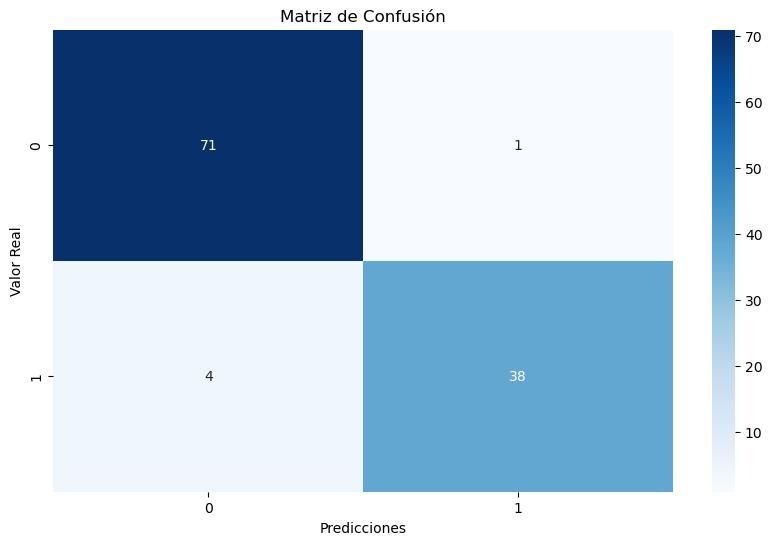

In [62]:
# Crear Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Titulo
plt.title("Matriz de Confusión")

# Etiquetas de x y Y
plt.xlabel("Predicciones")
plt.ylabel("Valor Real")

# Mostrar el grafico
plt.show()

##### Reporte de Clasificación

En esta etapa se genera el reporte de clasificación para evaluar el desempeño del modelo de forma detallada, considerando métricas como precisión, recall, f1-score y soporte por clase. 

Este análisis permite obtener una visión integral del comportamiento del modelo KNeighborsClassifier, identificando su capacidad para clasificar correctamente cada categoría y detectando posibles desequilibrios en el rendimiento entre clases.

In [63]:
# Mostrar las metricas completas
print("\nReporte de Clasificación;")
print(classification_report(y_test, y_pred))


Reporte de Clasificación;
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



#### Insight del Reporte de Clasificación

El modelo obtuvo un desempeño sobresaliente, alcanzando un **accuracy del 96%**, lo que indica una alta capacidad para clasificar correctamente los datos.

- La **clase 0** presentó una precisión del **95%** y un recall del **99%**, mostrando excelente identificación de casos negativos.
- La **clase 1** alcanzó una precisión del **97%** y un recall del **90%**, evidenciando una muy buena detección de casos positivos.
- El **F1-Score** de ambas clases se mantiene alto (0.97 y 0.94), reflejando un equilibrio adecuado entre precisión y sensibilidad.

En general, el modelo demuestra ser robusto, confiable y con una capacidad predictiva muy eficiente sobre los datos evaluados.

##### Comparacion Real vs Predicho

Se comparan los valores reales con las predicciones generadas por el modelo para evaluar su nivel de precisión. Este análisis permite identificar diferencias entre el comportamiento esperado y el estimado.

In [64]:
# Crear Dataframe comparativo
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

# Mostrar la tabla
display(comparacion.head(10))

,Real,Predicho
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


##### Insight de Predicciones vs Valores Reales

La comparación entre los valores reales y las predicciones muestra que el modelo logró clasificar correctamente la mayoría de los casos evaluados.

- Se observan múltiples coincidencias entre los valores reales y predichos, evidenciando una buena capacidad de aprendizaje.
- Solo se identifica un error de clasificación en el registro 3, donde el modelo predijo `0` cuando el valor real era `1`.
- Esto indica que el modelo mantiene una alta precisión y un bajo nivel de errores en las predicciones realizadas.

En general, los resultados reflejan un modelo confiable y con un comportamiento predictivo consistente.

##### Grafico de Real vs Predicho.

Se construye una visualización que contrasta los valores reales y predichos, facilitando la evaluación del ajuste del modelo y su comportamiento general frente a los datos.

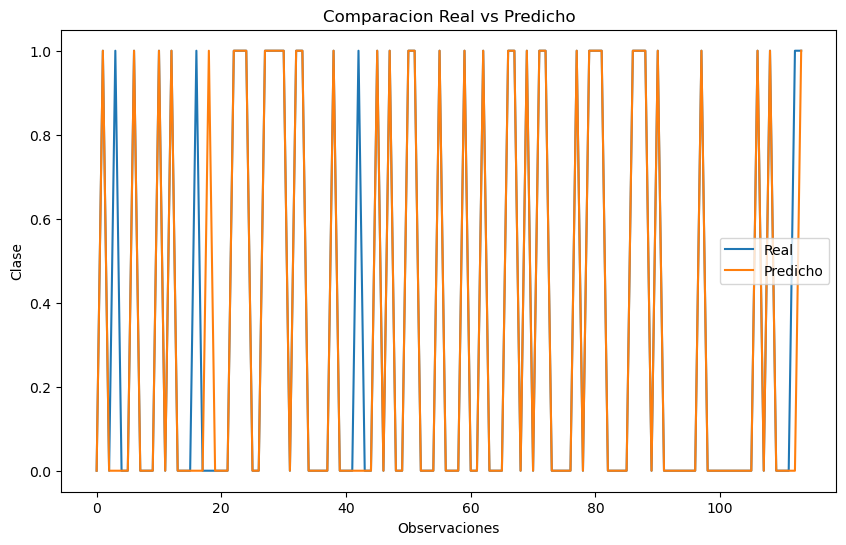

In [65]:
# Grqaficar valores reales
plt.plot(
    comparacion["Real"].values,
    label="Real"
)

# Graficar valores predichos
plt.plot(
    comparacion["Predicho"].values,
    label="Predicho"
)

plt.title("Comparacion Real vs Predicho")
plt.xlabel("Observaciones")
plt.ylabel("Clase")

plt.legend()

plt.show()

###### Insight del Gráfico Real vs Predicho

El gráfico de comparación entre los valores reales y las predicciones evidencia que el modelo mantiene un comportamiento muy cercano a los datos reales, ya que ambas líneas coinciden en la mayoría de las observaciones.

- La superposición entre la línea **Real** y **Predicho** indica una alta precisión en las clasificaciones realizadas.
- Existen pocas diferencias visibles entre ambas curvas, lo que refleja un bajo nivel de error.
- El modelo demuestra una buena capacidad para identificar correctamente las clases 0 y 1 a lo largo de las observaciones evaluadas.

En general, el gráfico confirma que el modelo presenta un rendimiento sólido, consistente y confiable en la predicción de datos.

## FASE 6. DESPLIEGUE

##### Probar una nueva predicción.

Se realiza una predicción con datos nuevos no vistos por el modelo, con el objetivo de validar su capacidad de generalización y simular su desempeño en un entorno real de aplicación.

In [66]:
# Tomar un paciente del dataset de prueba
nuevo_paciente = X_test.iloc[0:1]

# Escalar datos del nuevo paciente.
nuevo_paciente_scaled = scaler.transform(nuevo_paciente)

# Realizar la prediccion
prediccion = knn.predict(nuevo_paciente_scaled)

# Mostar el resultado
print("\nPredicción del nuevo paciente:")

# Validar el resultado
if prediccion[0] == 1:
    print("Tumor Maligno")
else:
    print("Tumor Benigno")



Predicción del nuevo paciente:
Tumor Benigno


##### Insight de la Predicción del Nuevo Paciente

El modelo clasificó al nuevo paciente como **Tumor Benigno**, lo que indica que, según los patrones aprendidos durante el entrenamiento, las características analizadas no presentan un comportamiento asociado a tumores malignos.

- La predicción refleja que el modelo pudo identificar similitudes con casos previamente clasificados como benignos.
- Este resultado demuestra la capacidad del algoritmo KNN para realizar clasificaciones basadas en la cercanía entre observaciones.
- Aun así, la predicción debe considerarse como apoyo analítico y no como un diagnóstico médico definitivo.

En general, el modelo muestra un desempeño adecuado para apoyar procesos de clasificación de tumores.

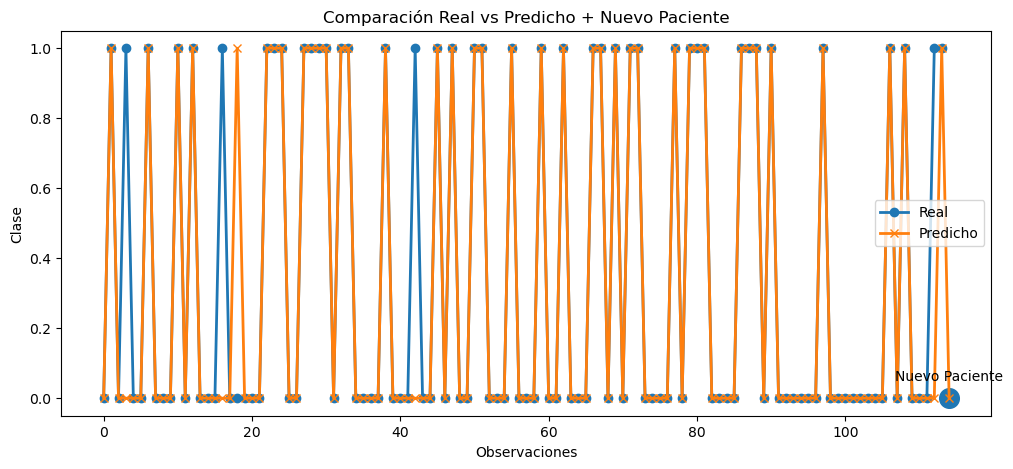

In [67]:
# Agregar nuevo paciente al final del gráfico
y_real_extendido = list(y_test.values) + [None]

y_pred_extendido = list(y_pred) + [
    prediccion[0]
]

# Crear figura
plt.figure(figsize=(12,5))

# Línea valores reales
plt.plot(
    y_real_extendido,
    marker='o',
    linewidth=2,
    label="Real"
)

# Línea valores predichos
plt.plot(
    y_pred_extendido,
    marker='x',
    linewidth=2,
    label="Predicho"
)

# Resaltar nuevo paciente
plt.scatter(
    len(y_pred_extendido)-1,
    prediccion[0],
    s=200
)

# Agregar texto
plt.text(
    len(y_pred_extendido)-1,
    prediccion[0] + 0.05,
    "Nuevo Paciente",
    ha="center"
)

# Título
plt.title(
    "Comparación Real vs Predicho + Nuevo Paciente"
)

# Etiquetas
plt.xlabel("Observaciones")
plt.ylabel("Clase")

# Leyenda
plt.legend()

# Mostrar gráfico
plt.show()

##### Conclusión del Proyecto

En este proyecto se desarrolló un modelo de Machine Learning utilizando el algoritmo **K-Nearest Neighbors (KNN)** para la clasificación de tumores en benignos y malignos. A través del proceso de análisis, preparación de datos, entrenamiento y evaluación del modelo, se obtuvo un desempeño altamente satisfactorio.

Los resultados obtenidos demostraron una alta capacidad predictiva, alcanzando un **96% de accuracy**, además de métricas elevadas de precisión, recall y F1-score, lo que evidencia que el modelo logra clasificar correctamente la mayoría de los casos evaluados. La matriz de confusión también confirmó un bajo nivel de errores de clasificación, especialmente en falsos positivos y falsos negativos.

Asimismo, las pruebas realizadas con nuevos datos permitieron validar que el modelo puede apoyar eficazmente la identificación de tumores benignos y malignos mediante patrones aprendidos durante el entrenamiento.

En conclusión, el algoritmo KNN demostró ser una técnica eficiente, confiable y fácil de interpretar para problemas de clasificación médica, convirtiéndose en una herramienta útil de apoyo para el análisis predictivo y la toma de decisiones basadas en datos.